In [47]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
     

In [48]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass
     

In [49]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost
     

In [50]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])
     

In [53]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}
class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []

        for action, (dr, dc) in MOVES.items():
            next_state = (state[0] + dr, state[1] + dc)

            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1
    
class SearchAlgorithm(ABC):
  

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        state = node.state

        for action in problem.actions(state):

            next_state = problem.result(state, action)

            cost = node.path_cost + problem.action_cost(
                state, action, next_state
            )

            yield Node(
                state=next_state,
                parent=node,
                action=action,
                path_cost=cost
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass
    

In [54]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [55]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.2, 0.2, 0.2)      

            elif start is not None and state == start:
                fill = (0.2, 0.4, 1.0)     

            elif goal is not None and state == goal:
                fill = (0.0, 0.8, 0.4)      

            elif state in path_set:
                fill = (1.0, 0.6, 0.0)      

            else:
                fill = (0.95, 0.95, 0.95)   

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [56]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        row, col = next_state
        return self.terrain_costs[row][col]

In [57]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [58]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    r1, c1 = state
    r2, c2 = goal
    return ((r1 - r2) ** 2 + (c1 - c2) ** 2) ** 0.5


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [ ]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0


for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [60]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0
     

In [ ]:
def search(self, problem: Problem) -> SearchResult:

   
    node = Node(state=problem.initial_state())

    frontier = PriorityQueue()
    counter = 0  # tie-breaker

    frontier.push((self.evaluation(node, problem), counter), node)

    reached = {node.state: node}

    nodes_expanded = 0
    max_frontier_size = 1


    while not frontier.is_empty():

        _, node = frontier.pop()

    
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=self.algorithm_name,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=len(reached)
            )

        nodes_expanded += 1

        
        for child in self.expand(problem, node):
            s = child.state

            if s not in reached or child.path_cost < reached[s].path_cost:

                reached[s] = child
                counter += 1

                frontier.push(
                    (self.evaluation(child, problem), counter),
                    child
                )

        max_frontier_size = max(max_frontier_size, len(frontier))

    
    return SearchResult(
        algorithm=self.algorithm_name,
        status="failure",
        solution=None,
        nodes_expanded=nodes_expanded,
        max_frontier_size=max_frontier_size,
        reached_count=len(reached)
    )

In [68]:
class BestFirstSearch(SearchAlgorithm):
    algorithm_name = "BestFirst"

    def __init__(self, heuristic=zero_heuristic):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        counter = itertools.count()  # tie-breaker, unique per push

        node = Node(state=problem.initial_state())

        frontier = []
        heapq.heappush(frontier, (self.evaluation(node, problem), next(counter), node))

        reached = {node.state: node}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            _, _, node = heapq.heappop(frontier)

            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached),
                )

            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    heapq.heappush(frontier, (self.evaluation(child, problem), next(counter), child))

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [62]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
    
        return self.h(node, problem)

In [63]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        
        return node.path_cost + self.h(node, problem)

In [70]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
    
        return node.path_cost + self.weight * self.h(node, problem)

In [71]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [ ]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)


walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


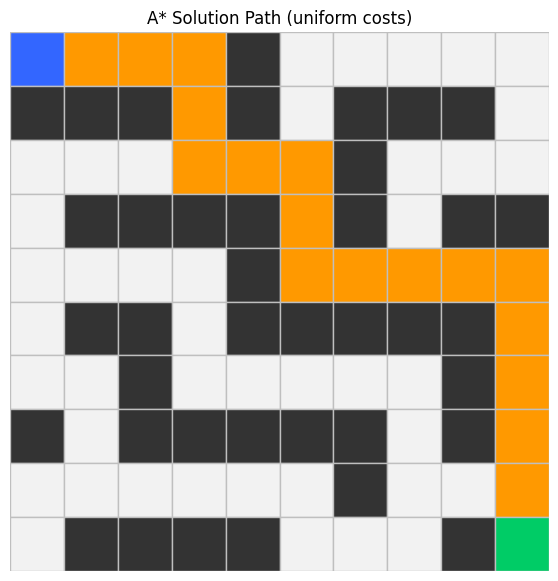

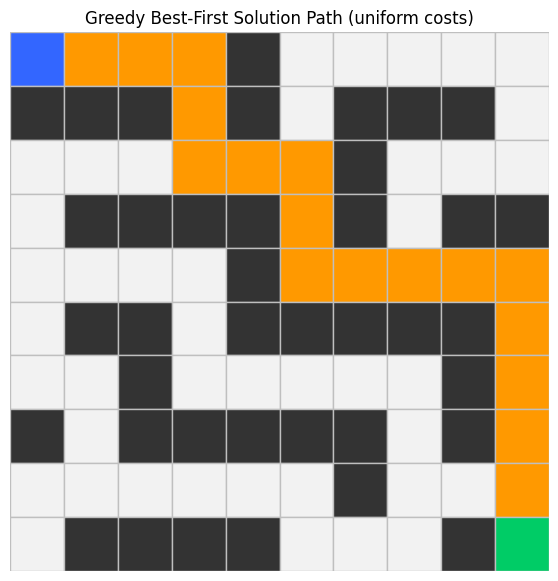

In [ ]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)
     


plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)
     

In [74]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


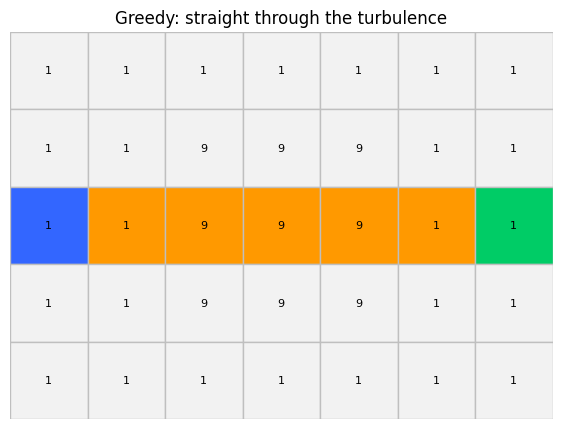

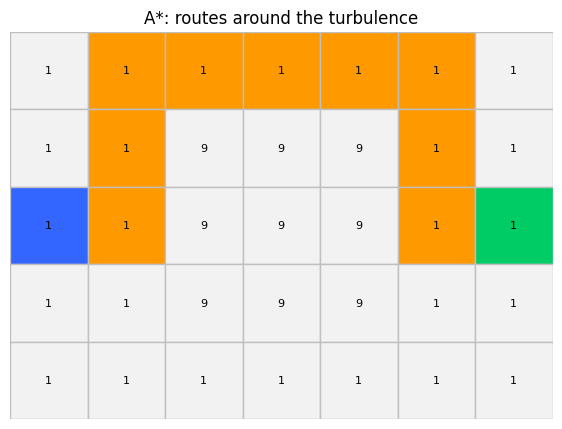

In [75]:
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)
     

In [76]:
def inflated_heuristic(factor: float):
    

    def h(state, goal):
        return factor * manhattan_distance(state, goal)

    return h
mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


1. The inflated heuristic bacame suboptimal on the mild turbulence map by 2 cost units.

2. On the mild turbulence map, the inflated heuristic expandede 23 fewer nodes.

3. I would accept an admissible heuristic when fast decision-making is more essential than optimality.

In [77]:


custom_grid_1 = [
    [0,0,0,0,0,0,0],
    [0,1,1,1,1,1,0],
    [0,0,0,0,0,1,0],
    [0,1,1,1,0,1,0],
    [0,0,0,1,0,0,0],
    [0,1,0,0,0,1,0],
    [0,0,0,1,0,0,0]
]

custom_costs_1 = [
    [1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1],
    [1,8,8,8,8,1,1],
    [1,1,1,1,8,1,1],
    [1,1,1,1,8,8,8],
    [1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1]
]

custom_start_1 = (0,0)
custom_goal_1 = (6,6)

custom_problem_1 = WeightedGridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    terrain_costs=custom_costs_1
)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,12,12,26,4,30
1,A*,success,12,12,25,4,29
2,Weighted A* (W=2),success,12,12,16,5,20
3,Greedy,success,14,14,14,6,20


In [ ]:
custom_grid_2 = [
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,1,0,0,0,0,0,1,0,0],
    [0,1,0,1,1,1,0,1,0,0],
    [0,1,0,1,0,1,0,1,0,0],
    [0,1,0,1,0,1,0,1,0,0],
    [0,1,0,1,1,1,0,1,0,0],
    [0,1,0,0,0,0,0,1,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,0,0,0,0,0,0,0,0,0]
]

custom_costs_2 = [
    [1]*10 for _ in range(10)
]

custom_start_2 = (0,0)
custom_goal_2 = (4,4)

custom_problem_2 = WeightedGridProblem(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    terrain_costs=custom_costs_2
)

custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]

show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,failure,None,None,44,4,44
1,A*,failure,None,None,44,7,44
2,Weighted A* (W=2),failure,None,None,44,8,44
3,Greedy,failure,None,None,44,8,44


16.1
1. h(n) estimates the remaining cost from the current state to the goal state. In this lab, h(n) comes from the grid and the coordinates of the current state and goal, provided by the drone's GPS.

2. The relaxed problem assumes that every move cost exactly one unit, the drone can always move directly to the toward the goal and ignores obstacles as well.

3. Manhattan distance dominates the Euclidean distance because it gives larger heuristic values while still remaining admissible.It's heuristic causes A* to expand fewer nodes.

4. Because every move is greater than or equal to one, Manhattan distance never overestimates the true remaining cost. If some cells cost o.5, the path cost become smaler than the Mahattan distance, making the heuristic to overestimate making it less admissible.





16.2 
1. Greedy ignores the accumulated path cost g(n). On the turbulence map, it was attracted toward the goal and entered expensive terrain, causing expensive solution.

2. Expanding fewer nodes only means been faster. It does not guarantee the cheapest or optimal path.

3. In times of emergency, the greedy's behaviour would actaully be acceptable.




16.3
1. The drone chooses routes by adding the the cost already incurred with an estimate of the cost of the path remaining to get to the goal state.

2. A goal node that is generated first may not be the cheapest route. Another cheaper path may still be in the frontier. Testing when the node is popped guarantees that the cheapest route is selected.

3. In non-uniform costs, a goal state can be discovered again, hence a dictionary is needed to store the path and its corresponding cost so that if a cheaper cost is discovered it can be replaced with the expensive ones.

4. A* expanded fewer nodes than UCS. This tells us that heuristics improve serach efficiency.





16.4 Admissibility and Consistency
1. A heuristic is admissible if it never overestimates the true remaining cost. A heuristic is consistent if it satifies h(n) <= c(n,a,n') + h(n')
Consistency implies admissibility.

2. The experiment confirmed the lecture's claim. Optimality is lost when the heuristic is not admissible.

3. Yes. 




16.5 Weighted A* and Trade-offs
1. W is 0 and 1 for Uniform-Cost Search and Standard A* respectively. Large W approaches the Greedy Best-First Search.

2. Weighted A* guarantees solution cost no greater than W times the optimal cost. In the experiments, the returned cost remained well within this bound.

3. I would choose Weighted A* with W = 2.




16.6 Memory and Real-World Drone Context
1. Priority Queue and reached dictionary makes A* memory-hungry. IDA* avoids this by doing repeated depth-first search.

2. The terrain cost could incorporate weather conditions, wind strength, battery level and risk associated with flying over certain areas.

3. The heuristic becomes inaacurate.

4. I would deploy A* with the Manhattan heuristic because it provides an excellent balance between optimality and efficiency.
